# Portfolio problem

In [105]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.bayes_conjugates import (
    sample_posterior,
    default_prior_params,
    get_log_partition_constant,
    get_posterior_params,
    derive_analytical_posterior_params,
)
from mis_dro.likelihood import sample_likelihood

In [106]:
mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

returns_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.007383,0.012783,0.005208,-0.038285,-0.012098,-0.056079,-0.041475,-0.032967,-0.023324,0.010955,...,0.024652,-0.027021,-0.015650,-0.009319,-0.027835,-0.026883,-0.008618,0.006533,0.051115,0.004274
1,0.014659,0.060496,-0.041451,0.014044,0.008151,0.003959,0.014423,0.039771,0.071641,0.014441,...,-0.108267,0.015873,0.023849,0.041915,0.063393,0.050251,-0.043478,0.012988,0.054975,0.046809
2,0.061602,0.028454,0.005405,0.023102,0.010126,0.011830,0.018950,0.016396,0.036207,0.026693,...,0.067451,0.000000,0.017083,0.107200,0.030769,0.040666,0.018176,0.022436,-0.018046,-0.002036
3,0.157034,0.076217,0.021505,0.029342,0.040078,0.052638,-0.037206,-0.013443,0.016138,0.045055,...,-0.037913,0.023438,0.015268,0.048307,0.067165,0.032176,0.000000,-0.018807,0.004088,0.002040
4,-0.002973,-0.042887,-0.036842,-0.019733,-0.013486,0.009256,-0.057971,0.002724,-0.010582,-0.013267,...,-0.013136,-0.041991,0.007514,0.007680,0.006994,0.008909,-0.040180,-0.022364,0.006101,-0.052846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,0.053573,0.002948,0.053774,0.014542,0.039465,0.034998,0.064654,0.029174,0.023364,0.020403,...,0.022334,-0.000341,0.023586,-0.037993,0.039939,0.003105,0.061533,0.063085,0.104431,0.026879
1359,0.006381,0.041936,-0.024272,0.008619,-0.000660,-0.023225,-0.013680,0.006321,-0.007807,0.029084,...,0.028417,0.049082,0.007722,0.026329,0.027990,-0.000929,0.009661,-0.021790,-0.027284,0.021828
1360,0.033067,0.012977,0.014683,-0.003530,0.027090,0.026488,0.022666,0.017130,0.009056,0.008390,...,0.012139,0.007404,0.018726,0.064299,0.075352,0.024166,0.027531,0.020063,0.043448,0.028452
1361,-0.006798,-0.005941,0.007175,0.008855,0.012866,-0.008401,-0.017532,-0.000749,0.002207,0.002847,...,0.017201,-0.005169,0.008736,-0.052225,-0.033638,-0.002622,-0.015194,-0.005885,-0.007511,0.001896


In [107]:
IN_SAMPLE_TIME_WINDOW = 52
OUT_OF_SAMPLE_TIME_WINDOW = 12  # number of weeks in out-of-sample period
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))

In [108]:
def get_portfolio_problem(num_stocks: int, num_cov_samples: int) -> cp.Problem:
    """Evaluate portfolio cost function with cvxpy assuming a Gaussian likelihood

    Args:
        num_stocks: Number of stocks in portfolio, i.e. dimension of random variable
        num_cov_samples: Number of covariance samples from the posterior

    Returns:
        Cvxpy problem object
    """
    # variables
    x = cp.Variable(num_stocks, name="x")

    # parameters
    epsilon_minus_constant = cp.Parameter(1, name="epsilon_minus_constant", nonneg=True)
    mu_post = cp.Parameter(num_stocks, name="mu_post")
    sqrt_cov_post_samples = [cp.Parameter((num_stocks, num_stocks), name=f"sqrt_cov_post_{i}") for i in range(num_cov_samples)]

    # objective function: maximise return whilst minimising variance
    portfolio_objective = cp.Minimize(- mu_post @ x + cp.sqrt(2 * epsilon_minus_constant) * (1.0 / float(num_cov_samples)) * cp.sum(
        [cp.norm(sqrt_cov_post_samples[i] @ x) for i in range(num_cov_samples)]
    ))

    # constraints
    constraints = [x >= 0, cp.sum(x) == 1]

    return cp.Problem(portfolio_objective, constraints)
    

In [112]:
problem = get_portfolio_problem(num_stocks, 1)
solutions = np.zeros((num_time_windows, num_stocks))
solution_returns = np.zeros((num_time_windows, OUT_OF_SAMPLE_TIME_WINDOW))
epsilon = 2.8
for j in range(num_time_windows):
    dim = num_stocks
    start_training_week = j * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
    end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
    start_test_week = end_training_week # inclusive
    end_test_week = start_test_week + OUT_OF_SAMPLE_TIME_WINDOW # not inclusive
    data = returns_df.iloc[start_training_week: end_training_week].values
    data_eval = returns_df.iloc[start_test_week: end_test_week].values

    posterior = "normal_inverse_wishart"
    theta_prior = default_prior_params(posterior, dim=dim)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    log_partition_constant = get_log_partition_constant(posterior, theta_posterior)
    
    mu_post, kappa_post, iota_post, Psi_post = theta_posterior

    problem.param_dict["epsilon_minus_constant"].value = np.array([epsilon - log_partition_constant])
    problem.param_dict["mu_post"].value  = mu_post
    problem.param_dict["sqrt_cov_post_0"].value = sp.linalg.sqrtm(Psi_post / (kappa_post - dim - 2))
    problem.solve(solver=cp.MOSEK, accept_unknown=True)

    solutions[j] = problem.var_dict["x"].value
    solution_returns[j] = data_eval @ solutions[j]


/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:237: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)


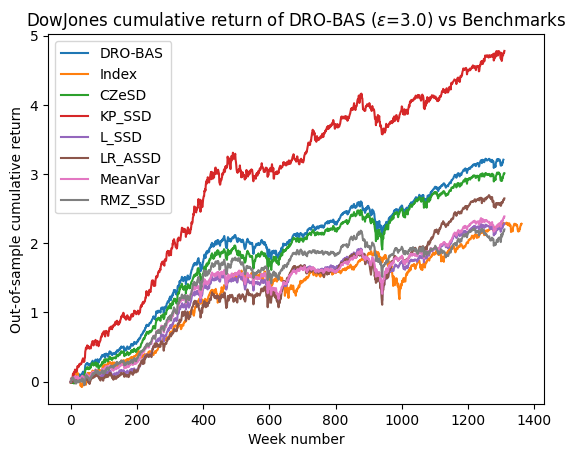

In [103]:
dro_bas_returns = solution_returns.flatten()
plt.plot(np.cumsum(dro_bas_returns), label="DRO-BAS")
plt.plot(np.cumsum(index_returns_df.values), label="Index")
for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    plt.plot(np.cumsum(baseline_returns), label=baseline_model)

plt.xlabel("Week number")
plt.ylabel("Out-of-sample cumulative return")
plt.title(dgp + r" cumulative return of DRO-BAS ($\epsilon$" + f"={epsilon}) vs Benchmarks")
plt.legend()

In [100]:
index_returns_df

,0
0,-0.012563
1,0.018087
2,0.014025
3,0.025652
4,-0.017408
...,...
1358,0.033751
1359,0.009089
1360,0.022911
1361,-0.005020


In [113]:
num_time_windows

109